# 05 · Apply the flux processing chain to each variant

Notebooks 01 to 04 compare the **Level-1** EddyPro fluxes (the raw half-hourly
`FN2O` / `FCH4` straight from the FLUXNET CSVs). This notebook takes the next
step: it runs each processing variant through `diive`'s post-processing
**flux processing chain** (the Swiss FluxNet workflow) so the time-lag
comparison can be repeated on quality-controlled, USTAR-filtered fluxes instead
of the raw budget.

The chain is applied identically to every variant; only the input flux differs,
so any difference that survives is still attributable to the time-lag setting.
The levels run here:

- **L2** quality-flag expansion (SSITC, gas completeness, spectral correction,
  raw-data screening VM97).
- **L3.1** storage correction (set to zero for N₂O / CH₄, see note below).
- **L3.2** outlier removal (absolute limits, rolling z-score, local SD), with
  per-gas settings.
- **L3.3** USTAR turbulence filtering, three constant thresholds
  (CUT_16 / CUT_50 / CUT_84).

Gap-filling (L4.1) and partitioning (L4.2) are **not** run here: they need meteo
driver columns (TA, SW_IN, VPD) that are not in the flux files. The output is
therefore the measured, quality-controlled flux per USTAR scenario.

- **Input:** `data/01-eddypro_fluxes_level-1_parquet/` (the full per-variant
  tables; the chain needs the EddyPro flag and `USTAR` columns, so the
  column subsets from notebook 02 are not enough).
- **Output:** `data/05-flux_processing_chain_parquet/` (one `*_fpc.parquet` per
  variant and gas, holding every flag / QCF / filtered-series column the chain
  produced).

## Imports

In [13]:
from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from diive.core.io.files import load_parquet, save_parquet
from diive.flux.fluxprocessingchain import (
    init_flux_data,
    run_level2,
    run_level31,
    make_level32_detector,
    run_level32,
    run_level33_constant_ustar,
)

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

Everything that defines the run is collected here so it stays auditable and easy
to adjust. The variants are the same study variable used throughout the repo
(`ANALYZERS`); the chain settings below are the parts you will tune.

In [14]:
INDIR = Path("../data/01-eddypro_fluxes_level-1_parquet")
OUTDIR = Path("../data/05-flux_processing_chain_parquet")
OUTDIR.mkdir(parents=True, exist_ok=True)
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

# Analysis year (matches notebooks 02 and 04).
YEAR = 2021

# The five time-lag variants per analyzer (the study variable).
ANALYZERS = {
    "QCL": ["QCL-1", "QCL-2", "QCL-3", "QCL-4", "QCL-5"],
    "LGR": ["LGR-1", "LGR-2", "LGR-3", "LGR-4", "LGR-5"],
}

# The two gas fluxes processed, one chain run each.
GASES = ["FN2O", "FCH4"]

### Site metadata

`init_flux_data` needs the site coordinates and UTC offset to compute potential
radiation and the daytime / nighttime split. The QCF acceptance threshold decides
which quality classes are kept: `accept_qcf_below=2` keeps QCF=0 (all tests pass)
and QCF=1 (soft warnings), the conventional FLUXNET choice; set it to 1 to keep
only the strictest QCF=0.

> **Check these for CH-Cha (Chamau) before a production run.**

In [15]:
SITE_LAT = 47.210227   # CH-Cha (Chamau), decimal degrees
SITE_LON = 8.410645    # CH-Cha (Chamau), decimal degrees
UTC_OFFSET = 1       # hours
NIGHTTIME_THRESHOLD = 20  # W m-2 potential radiation; below this = nighttime
ACCEPT_QCF_BELOW = 2      # keep QCF in {0, 1}; set to 1 for QCF=0 only

### USTAR scenarios (Level-3.3)

Three constant USTAR thresholds are applied as separate scenarios, the same value
for every variant. The labels CUT_16 / CUT_50 / CUT_84 are the 16th / 50th / 84th
percentiles of the FLUXNET USTAR distribution.

> **TODO: replace the placeholder thresholds below with your CH-Cha values
> (m s⁻¹).** Order does not matter, but conventionally CUT_16 < CUT_50 < CUT_84.

In [16]:
# label -> constant USTAR threshold (m s-1). PLACEHOLDERS -- replace.
USTAR_THRESHOLDS = {
    "CUT_16": 0.052945,
    "CUT_50": 0.069898,
    "CUT_84": 0.092841,
}

### Level-2 quality-flag tests

Each EddyPro test is switched on with `{'apply': True, ...}`. These are the
universal tests that do not need an analyzer-specific input column. The
signal-strength test is left off because the QCL / LGR signal-strength column is
not configured here; add it if you have one. `raw_data_screening_vm97` enables
the spike and dropout sub-tests (Vickers & Mahrt 1997).

In [17]:
LEVEL2_TESTS = {
    "ssitc": {"apply": True, "setflag_timeperiod": None},
    "gas_completeness": {"apply": True},
    "spectral_correction_factor": {"apply": True},
    "raw_data_screening_vm97": {
        "apply": True,
        "spikes": True, "amplitude": False, "dropout": True,
        "abslim": False, "skewkurt_hf": False, "skewkurt_sf": False,
        "discont_hf": False, "discont_sf": False,
    },
}

### Level-3.2 outlier settings, per gas

Outlier removal is a sequence of tests; each one screens the survivors of the
previous. The settings below are the per-gas values from the earlier test run:

- **Absolute limits** flag values outside a plausible physical range.
- **Rolling z-score** flags points far from a local mean (`winsize` records),
  repeated until no new outliers appear.
- **Local SD** flags points far from a rolling median in units of a rolling
  standard deviation, also repeated.

`winsize` is in records; at 30-min sampling `48*3` is three days.

In [18]:
OUTLIER_SETTINGS = {
    # FN2O: nmol N2O m-2 s-1
    "FN2O": {
        "abslim": (-5, 70),        # flag outside [-5, 70]
        "zscore_thres": 10,        # rolling z-score threshold
        "localsd_n_sd": 8,         # local SD multiplier
        "winsize": 48 * 3,         # rolling window (records) for both tests
    },
    # FCH4: nmol CH4 m-2 s-1
    "FCH4": {
        "abslim": (-100, 1100),    # flag outside [-100, 1100]
        "zscore_thres": 8,
        "localsd_n_sd": 7,
        "winsize": 48 * 3,
    },
}

### Storage correction (Level-3.1)

The chain runs storage correction between L2 and L3.2. N₂O and CH₄ have no
single-point storage profile here, so the storage term is set to zero (the flux
passes through unchanged, `NEE = flux + 0`) to keep the chain ordering intact. If
your EddyPro output carries a usable single-point storage term for these gases,
set `SET_STORAGE_TO_ZERO = False` and `GAPFILL_STORAGE = True` instead.

In [19]:
SET_STORAGE_TO_ZERO = True
GAPFILL_STORAGE = False

## Load the full flux tables

The chain reads the **full** per-variant tables (not the column subsets), because
L2 needs the EddyPro flag columns and L3.3 needs `USTAR`. `init_flux_data`
computes its own `SW_IN_POT` / `DAYTIME` / `NIGHTTIME` and refuses to run if those
names already exist, so they are dropped on load.

In [20]:
_RESERVED = ("SW_IN_POT", "DAYTIME", "NIGHTTIME")


def load_full(code):
    """Load one variant's full flux table, restricted to YEAR."""
    df = load_parquet(filepath=str(INDIR / f"{code}.parquet"))
    df = df.loc[df.index.year == YEAR]
    df = df.drop(columns=[c for c in _RESERVED if c in df.columns])
    return df


codes = [c for codes in ANALYZERS.values() for c in codes]
print(f"{len(codes)} variant table(s) to process: {codes}")

10 variant table(s) to process: ['QCL-1', 'QCL-2', 'QCL-3', 'QCL-4', 'QCL-5', 'LGR-1', 'LGR-2', 'LGR-3', 'LGR-4', 'LGR-5']


## The processing chain

One function runs the full L2 → L3.1 → L3.2 → L3.3 chain for a single variant and
gas. Each level returns a new `FluxLevelData` container (the chain is composable
and does not mutate its input), so the steps read top to bottom in order. The
outlier tests (L3.2) are added one at a time with `addflag()` between them, so
each test screens what the previous one left.

In [21]:
def run_chain_one(df, gas):
    """Run L2..L3.3 for one gas on one variant's dataframe; return FluxLevelData."""
    s = OUTLIER_SETTINGS[gas]

    # Build the container: potential radiation, day/night flags, site metadata.
    data = init_flux_data(
        df=df,
        fluxcol=gas,
        site_lat=SITE_LAT,
        site_lon=SITE_LON,
        utc_offset=UTC_OFFSET,
        nighttime_threshold=NIGHTTIME_THRESHOLD,
        daytime_accept_qcf_below=ACCEPT_QCF_BELOW,
        nighttime_accept_qcf_below=ACCEPT_QCF_BELOW,
    )

    # L2: expand EddyPro quality flags into the combined quality flag (QCF).
    data = run_level2(data, **LEVEL2_TESTS)

    # L3.1: storage correction (set to zero here, see config note).
    data = run_level31(
        data,
        set_storage_to_zero=SET_STORAGE_TO_ZERO,
        gapfill_storage_term=GAPFILL_STORAGE,
    )

    # L3.2: outlier removal, three tests in sequence with the per-gas settings.
    data, sod = make_level32_detector(data)
    sod.flag_outliers_abslim_test(minval=s["abslim"][0], maxval=s["abslim"][1])
    sod.addflag()
    sod.flag_outliers_zscore_rolling_test(
        thres_zscore=s["zscore_thres"], winsize=s["winsize"], repeat=True)
    sod.addflag()
    sod.flag_outliers_localsd_test(
        n_sd=s["localsd_n_sd"], winsize=s["winsize"], repeat=True)
    sod.addflag()
    data = run_level32(data, outlier_detector=sod)

    # L3.3: USTAR filtering, one constant threshold per scenario.
    data = run_level33_constant_ustar(
        data,
        thresholds=list(USTAR_THRESHOLDS.values()),
        threshold_labels=list(USTAR_THRESHOLDS.keys()),
        showplot=False,
        verbose=False,
    )
    return data

## Run for all variants and gases

Each (variant, gas) pair is processed independently. The full chain output
(`data.fpc_df`, every flag and filtered-series column) is saved to Parquet, and
the USTAR-filtered series are kept in memory for the comparison below. A failed
run is reported and skipped so one problem does not stop the batch.

In [22]:
results = {}   # (code, gas, scenario) -> USTAR-filtered (QCF-accepted) flux series
failures = {}  # (code, gas) -> error message

for analyzer, analyzer_codes in ANALYZERS.items():
    for code in analyzer_codes:
        df = load_full(code)
        for gas in GASES:
            print(f"\n=== {code} / {gas} ===")
            try:
                data = run_chain_one(df.copy(), gas)
            except Exception as e:  # keep the batch going; inspect afterwards
                failures[(code, gas)] = repr(e)
                print(f"  FAILED: {e!r}")
                continue

            # Save the full chain output.
            save_parquet(filename=f"{code}_{gas}_fpc", data=data.fpc_df,
                         outpath=str(OUTDIR))

            # Keep the per-scenario QCF-accepted series for the comparison.
            for scen in USTAR_THRESHOLDS:
                results[(code, gas, scen)] = data.levels.filteredseries_level33_qcf[scen]

print(f"\nDone. {len(results) // len(USTAR_THRESHOLDS)} run(s) succeeded, "
      f"{len(failures)} failed.")
if failures:
    for key, msg in failures.items():
        print(f"  {key}: {msg}")

> Loaded .parquet file ..\data\01-eddypro_fluxes_level-1_parquet\QCL-1.parquet (0.032 seconds).


=== QCL-1 / FN2O ===


────────────────────────────────────────── Initializing flux data: FN2O ───────────────────────────────────────────

> Detected base variable N2O for FN2O. (N2O was used to calculate FN2O.)

> Potential radiation calculated (SW_IN_POT)

...

> running FlagSingleConstantUstarThreshold ...

> running FlagSingleConstantUstarThreshold ...

> running FlagSingleConstantUstarThreshold ...

> Saved file ..\data\05-flux_processing_chain_parquet\LGR-5_FCH4_fpc.parquet (0.017 seconds).


Done. 20 run(s) succeeded, 0 failed.


## Cumulative comparison after quality control

Does the time-lag budget gap from notebook 04 survive the chain? For one USTAR
scenario (`PLOT_SCENARIO`), the running sum of the quality-controlled flux is
drawn per variant, one panel per analyzer and gas.

As in notebook 04, the comparison is **paired**: within each analyzer the
variants are aligned on the timestamp index and only the half-hours where *every*
variant has a quality-controlled flux are kept. Quality control removes a
different set of half-hours per variant, so this common-sample step is what makes
the cumulative lines comparable. The panel title reports how many variants and
common half-hours (`n`) went into it.

Saved ..\figures\05_cumulative_qc_cut_50.png


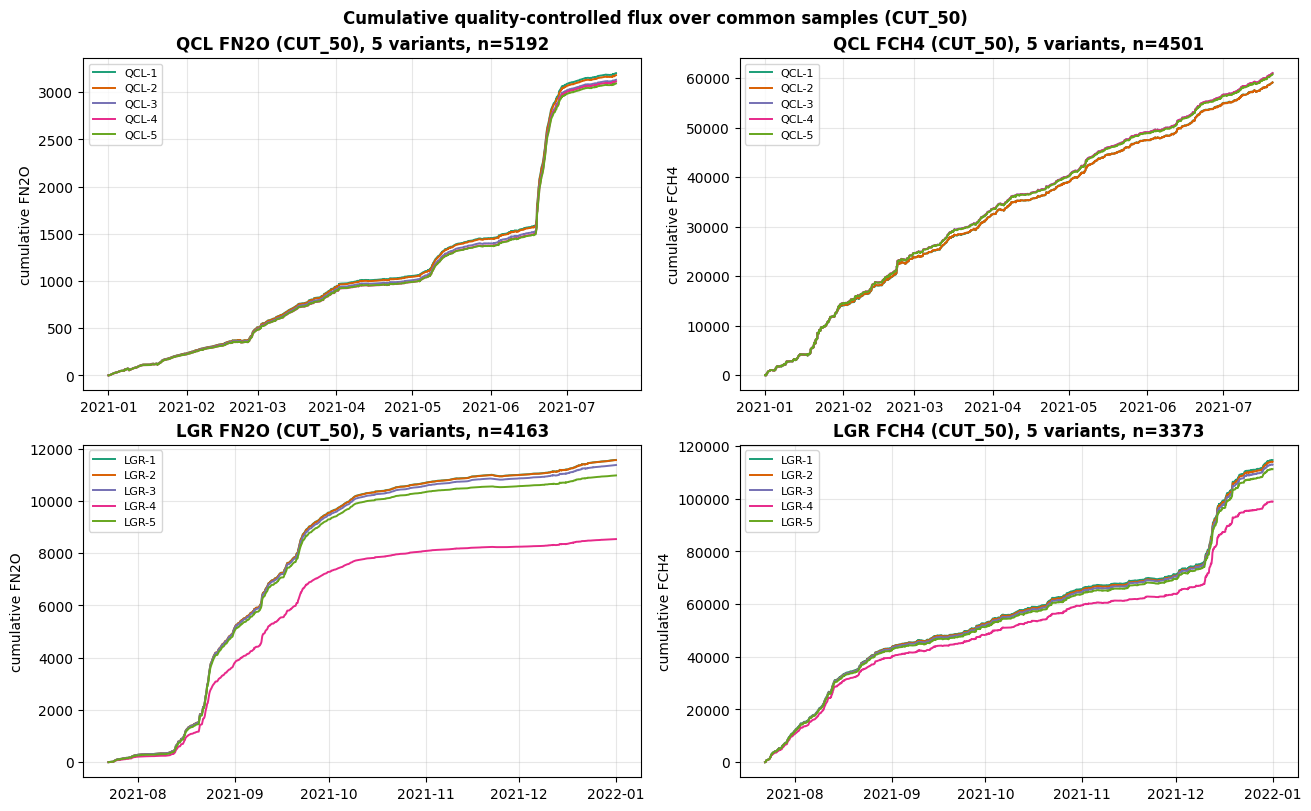

In [23]:
PLOT_SCENARIO = "CUT_50"
VAR_COLORS = {"-1": "#1b9e77", "-2": "#d95f02", "-3": "#7570b3",
              "-4": "#e7298a", "-5": "#66a61e"}

fig, axes = plt.subplots(len(ANALYZERS), len(GASES),
                         figsize=(13, 8), constrained_layout=True, squeeze=False)
for ri, (analyzer, analyzer_codes) in enumerate(ANALYZERS.items()):
    for ci, gas in enumerate(GASES):
        ax = axes[ri, ci]

        # Align the variants on the timestamp index and keep only the half-hours
        # where EVERY variant has a quality-controlled flux (the paired,
        # common-sample set, as in notebook 04). The cumulative sums then all run
        # over identical timestamps, so the lines are directly comparable.
        frame = pd.DataFrame({
            code: results[(code, gas, PLOT_SCENARIO)]
            for code in analyzer_codes if (code, gas, PLOT_SCENARIO) in results
        })
        common = frame.dropna(how="any")
        cum = common.cumsum()
        for code in common.columns:
            suffix = "-" + code.split("-", 1)[1]
            ax.plot(cum.index, cum[code], lw=1.4,
                    color=VAR_COLORS.get(suffix), label=code)

        ax.set_title(f"{analyzer} {gas} ({PLOT_SCENARIO}), "
                     f"{common.shape[1]} variants, n={common.shape[0]}",
                     fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        ax.set_ylabel(f"cumulative {gas}")

fig.suptitle(f"Cumulative quality-controlled flux over common samples "
             f"({PLOT_SCENARIO})", fontweight="bold")
out = FIGDIR / f"05_cumulative_qc_{PLOT_SCENARIO.lower()}.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved {out}")
plt.show()

## Runtime

In [24]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-06-23 14:28:39
End:      2026-06-23 14:28:56
Runtime:  0:00:17.358792
